<a href="https://colab.research.google.com/github/thiagolimaop/heart_disease/blob/main/Analysis_and_prediction_of_heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis and prediction of heart disease

## 1. Problem Definition

The dataset used comes from the Cleveland Clinical Foundation Medical Center. This dataset is a subset of the original dataset containing 75 attributes collected together three other medical institutions in Europe. The objective of this work is to perform descriptive and exploratory analyses to support the construction of a heart disease classification model in patients through supervised learning.

### **Attribute information**

1. **age** - patient's age;
2. **sex** - patient's gender;
  - 0: Female
  - 1: Male
3. **cp** - type of chest pain;
  - 1: Typical angina;
  - 2: Atypical angina;
  - 3: Non-angina pain;
  - 4: Asymptomatic;
4. **trtbps** - Resting blood pressure (in mm Hg);
5. **chol** - cholesterol in mg/dl obtained via BMI sensor;
6. **fbs** - Fasting blood sugar > 120 mg/dl?
  - 0: False
  - 1: True
7. **restecg** - electrocardiographic results in safety
  - 0: normal
  - 1: having ST-T wave abnormalities (T wave inversions and/or ST elevation or depression > 0.05 mV)
  - 2: showing probable or definite left ventricular hypertrophy according to Estes' criteria.
8. **thalachh** - maximum heart rate reached;
9. **exgn** - Exercise-induced angina;
10. **oldpeak** - Exercise-induced ST depression relative to rest;
11. **slp** - ST segment peak slope during exercise;
12. **caa** - Number of major vessels (ranging from 0 to 3) colored by fluoroscopy;
13. **thall** - myocardial perfusion test with thallium;
  - 1: defect fixed
  - 2: normal
  - 3: reversible defect
14. **output** - heart disease diagnosis
 - 0: < 50% reduction in diameter. Lower chance of heart disease.
 - 1: > 50% narrowing of the diameter. Increased risk of heart disease.

In [ ]:
# Importing the libraries used

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms # to handling missing data
import matplotlib as mpl
from abc import ABC, abstractmethod
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler # to normalization
from sklearn.preprocessing import StandardScaler # to standardization

## 2. Data Loading

Let's start by loading the .csv file using the Pandas package.

In [ ]:
df_src = pd.read_csv('https://raw.githubusercontent.com/thiagolimaop/heart_disease/main/heart.csv')
df_src.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


As explained earlier in the data understanding section, many qualitative attributes are represented by numbers. Therefore, to facilitate clarity and interpretation of the data and the creation of graphs and visualizations, we will convert these numerical attributes into strings.

In [ ]:
# Dictionary for mapping numeric values ​​to strings

gender_mapping = {0: 'Female', 1: 'Male'}
cp_mapping = {0: 'Asymptomatic', 1: 'Typical Angina', 2: 'Atypical Angina', 3: 'Non-angina pain'}
fsb_mapping = {0: 'False', 1: 'True'}
restecg_mapping = {0: 'Normal', 1: 'Wave abnormality', 2: 'Ventricular Hypertrophy'}
exng_mapping = {0: 'No', 1: 'Yes'}
slp_mapping = {0: 'Ascending', 1: 'Flat', 2: 'Descendant'}
thall_mapping = {0: '', 1: 'Defect Fixed', 2: 'Normal', 3: 'Reversible Defect'}

df = df_src.copy()

df['sex'] = df['sex'].map(gender_mapping)
df['cp'] = df['cp'].map(cp_mapping)
df['fbs'] = df['fbs'].map(fsb_mapping)
df['restecg'] = df['restecg'].map(restecg_mapping)
df['exng'] = df['exng'].map(exng_mapping)
df['slp'] = df['slp'].map(slp_mapping)
df['thall'] = df['thall'].map(thall_mapping)

df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,Male,Non-angina pain,145,233,True,Normal,150,No,2.3,Ascending,0,Defect Fixed,1
1,37,Male,Atypical Angina,130,250,False,Wave abnormality,187,No,3.5,Ascending,0,Normal,1
2,41,Female,Typical Angina,130,204,False,Normal,172,No,1.4,Descendant,0,Normal,1
3,56,Male,Typical Angina,120,236,False,Wave abnormality,178,No,0.8,Descendant,0,Normal,1
4,57,Female,Asymptomatic,120,354,False,Wave abnormality,163,Yes,0.6,Descendant,0,Normal,1


## 3. Data Analysis

Let's start by examining the dimensions of the dataset, its information, and some examples of rows.

In [ ]:
# Shows the dimensions of the dataset.
df.shape

(303, 14)

In [ ]:
# Mostra as informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    object 
 6   restecg   303 non-null    object 
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    object 
 11  caa       303 non-null    int64  
 12  thall     303 non-null    object 
 13  output    303 non-null    int64  
dtypes: float64(1), int64(6), object(7)
memory usage: 33.3+ KB


In [ ]:
# Show the first 10 rows of the dataset.
df.head(10)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,Male,Non-angina pain,145,233,True,Normal,150,No,2.3,Ascending,0,Defect Fixed,1
1,37,Male,Atypical Angina,130,250,False,Wave abnormality,187,No,3.5,Ascending,0,Normal,1
2,41,Female,Typical Angina,130,204,False,Normal,172,No,1.4,Descendant,0,Normal,1
3,56,Male,Typical Angina,120,236,False,Wave abnormality,178,No,0.8,Descendant,0,Normal,1
4,57,Female,Asymptomatic,120,354,False,Wave abnormality,163,Yes,0.6,Descendant,0,Normal,1
5,57,Male,Asymptomatic,140,192,False,Wave abnormality,148,No,0.4,Flat,0,Defect Fixed,1
6,56,Female,Typical Angina,140,294,False,Normal,153,No,1.3,Flat,0,Normal,1
7,44,Male,Typical Angina,120,263,False,Wave abnormality,173,No,0.0,Descendant,0,Reversible Defect,1
8,52,Male,Atypical Angina,172,199,True,Wave abnormality,162,No,0.5,Descendant,0,Reversible Defect,1
9,57,Male,Atypical Angina,150,168,False,Wave abnormality,174,No,1.6,Descendant,0,Normal,1


In [ ]:
# Shows the last 10 rows of the dataset
df.tail(10)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
293,67,Male,Atypical Angina,152,212,False,Normal,150,No,0.8,Flat,0,Reversible Defect,0
294,44,Male,Asymptomatic,120,169,False,Wave abnormality,144,Yes,2.8,Ascending,0,Defect Fixed,0
295,63,Male,Asymptomatic,140,187,False,Normal,144,Yes,4.0,Descendant,2,Reversible Defect,0
296,63,Female,Asymptomatic,124,197,False,Wave abnormality,136,Yes,0.0,Flat,0,Normal,0
297,59,Male,Asymptomatic,164,176,True,Normal,90,No,1.0,Flat,2,Defect Fixed,0
298,57,Female,Asymptomatic,140,241,False,Wave abnormality,123,Yes,0.2,Flat,0,Reversible Defect,0
299,45,Male,Non-angina pain,110,264,False,Wave abnormality,132,No,1.2,Flat,0,Reversible Defect,0
300,68,Male,Asymptomatic,144,193,True,Wave abnormality,141,No,3.4,Flat,2,Reversible Defect,0
301,57,Male,Asymptomatic,130,131,False,Wave abnormality,115,Yes,1.2,Flat,1,Reversible Defect,0
302,57,Female,Typical Angina,130,236,False,Normal,174,No,0.0,Flat,1,Normal,0


In [ ]:
# Checks the dataset type for each attribute
df.dtypes

,0
age,int64
sex,object
cp,object
trtbps,int64
chol,int64
fbs,object
restecg,object
thalachh,int64
exng,object
oldpeak,float64


In [ ]:
# Displays a descriptive statistical summary of the dataset
df.describe()

,age,trtbps,chol,thalachh,oldpeak,caa,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.623762,246.264026,149.646865,1.039604,0.729373,0.544554
std,9.082101,17.538143,51.830751,22.905161,1.161075,1.022606,0.498835
min,29.000000,94.000000,126.000000,71.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,211.000000,133.500000,0.000000,0.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000,1.000000
75%,61.000000,140.000000,274.500000,166.000000,1.600000,1.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,4.000000,1.000000


In [ ]:
# Check the distribution of the classes
df.groupby('output').size()

,0
output,
0,138
1,165


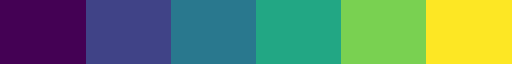

['#440154', '#414487', '#2a788e', '#22a884', '#7ad151', '#fde725']

In [ ]:
# Define color palette

# alternative A: Manually defining colors from a hexadecimal color list
# coresViridis = ["#440154","#3b528b","#21918c","#5ec962","#fde725"]

# alternative B: Defining colors using Matplotlib's own palette
# the Viridis palette is robust for people with color blindness.
vcmap = plt.get_cmap("viridis", 6) # one more than necessary to avoid using yellow

# displays the color map
display(vcmap)

# Convert the color map into a vector for use with individual colors
coresViridis = [mpl.colors.rgb2hex(vcmap(i)) for i in range(6)] # extracts color list in hex
display(coresViridis)

# defines a default color
corDefault = coresViridis[1]

# Load a stylesheet (optional - for aesthetic reasons)
plt.style.use("ggplot")

# Modify some additional graphic parameters (optional - aesthetic reasons)
plt.rc("axes", facecolor="#fafafa", grid = True)
plt.rc("grid", color = "#f0f0f0")
plt.rc("axes", edgecolor="#cccccc", lw=0.1)

/tmp/ipykernel_21512/2020089303.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=self.attr, x="output", data=df, palette=coresViridis, ax=ax2)
/tmp/ipykernel_21512/2020089303.py:26: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(y=self.attr, x="output", data=df, palette=coresViridis, ax=ax2)


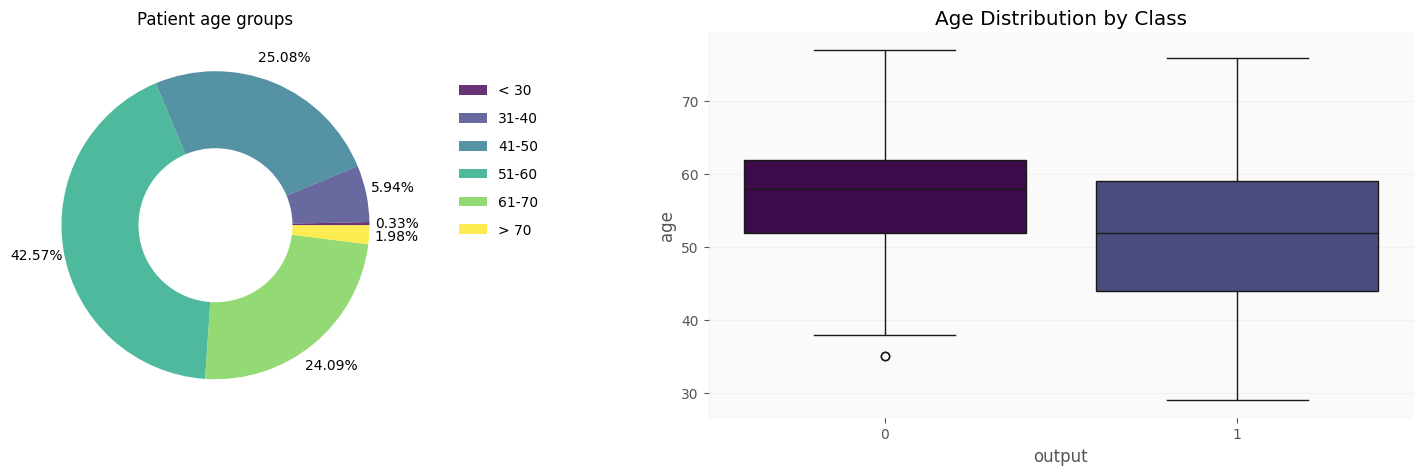

In [ ]:
class NumericalDistribuition(ABC):
    def __init__(self, attr, pie_title, pie_legends, figsize, box_plot_title):
        self.attr = attr
        self.pie_title = pie_title
        self.pie_legends = pie_legends
        self.figsize = figsize
        self.box_plot_title = box_plot_title

    @abstractmethod
    def grouping(self, value):
        pass

    def display_plot(self, df, _class):
        # Create a figure with one axis for each graph
        fig, (ax1, ax2) = plt.subplots(1, 2,  figsize=self.figsize)

        # Creating the summarized dataframe
        df_chart = df[self.attr].apply(_class.grouping).value_counts(sort=False)

        # Plot the pie chart on the first axis
        ax1.pie(df_chart.sort_index(), autopct='{:.2f}%'.format, wedgeprops={'width':0.5,'alpha':0.8}, pctdistance=1.18, colors=coresViridis)
        ax1.legend(self.pie_legends, frameon=False, bbox_to_anchor=(1.1,0.9), labelspacing=1)
        ax1.set_title(self.pie_title, fontsize=12)

        # Plot the boxplot along the second axis
        sns.boxplot(y=self.attr, x="output", data=df, palette=coresViridis, ax=ax2)

        # Adjust the titles and captions
        ax2.set_title(self.box_plot_title)

        plt.show()


# Data for the pie chart
attr = 'age'
pie_title = 'Patient age groups'
pie_legends = ['< 30','31-40','41-50','51-60','61-70', '> 70']
figsize = (20, 5)
box_plot_title = 'Age Distribution by Class'


class AgeChart(NumericalDistribuition):
    def grouping(value):
        if value < 30:
            return 0
        elif value >= 30 and value <= 40:
            return 1
        elif value >= 40 and value <= 50:
            return 2
        elif value >= 50 and value <= 60:
            return 3
        elif value >= 60 and value <= 70:
            return 4
        else:
            return 5

charts = AgeChart(attr, pie_title, pie_legends, figsize, box_plot_title)
charts.display_plot(df, AgeChart)


It is possible to see from the chart that **more than 90%** of the patients are **40 years of age or older**. Furthermore, it is possible to see that the age distributions by output class have a small difference, which makes the **age** attribute probably relevant to the classification model.

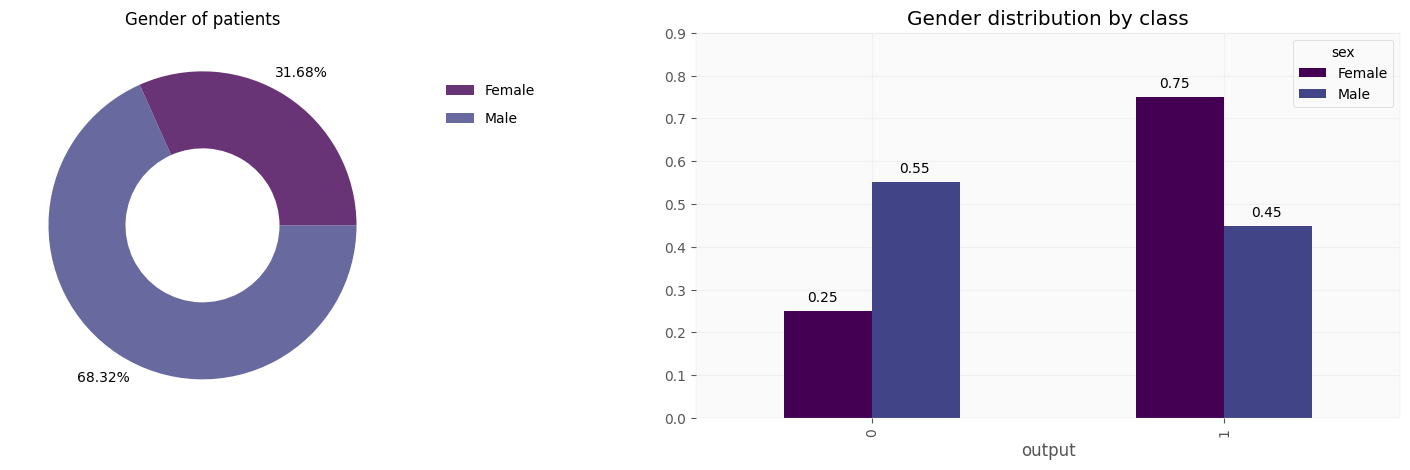

In [ ]:
class CategoricalDistribuition(ABC):
    def __init__(self, attr, pie_title, figsize, bar_title, initial, step):
        self.attr = attr
        self.pie_title = pie_title
        self.figsize = figsize
        self.bar_title = bar_title
        self.initial = initial
        self.step = step

    def display_plot(self, df):
        # Create a figure with one axis for each graph.
        fig, (ax1, ax2) = plt.subplots(1, 2,  figsize=self.figsize)

        # Data for the pie chart
        labels = sorted(list(df[self.attr].unique()))

        # Plot the pie chart on the first axis
        ax1.pie(df[self.attr].value_counts().sort_index(), autopct='{:.2f}%'.format, wedgeprops={'width':0.5,'alpha':0.8}, pctdistance=1.18, colors=coresViridis)
        ax1.legend(labels, frameon=False, bbox_to_anchor=(1.1,0.9), labelspacing=1)
        ax1.set_title(self.pie_title, fontsize=12)

        # Generate the cross-frequency table
        crosstab = pd.crosstab(df[self.attr], df['output'], normalize='index')

        # Plot the bar chart with the distributions on the second axis
        dist = crosstab.transpose()
        dist.plot(kind='bar', color=coresViridis, ax=ax2)

        # Add the values ​​to the top of the bars in the output class groups
        for i in range(len(dist)):
            valor = dist.iloc[i].values
            for j, v in enumerate(valor):
                x = i + (j * self.step) - self.initial
                ax2.text(x, v + 0.015, str(round(v, 2)), ha='center', va='bottom')

        # Adjust the titles and captions
        ax2.set_title(self.bar_title)
        y = dist.values.flatten()
        plt.ylim(0, max(y)+0.15)

        plt.show()


# Data for the pie chart
attr = 'sex'
pie_title = 'Gender of patients'
figsize = (20, 5)
bar_title = 'Gender distribution by class'
initial = 0.14
step = 0.26

charts = CategoricalDistribuition(attr, pie_title, figsize, bar_title, initial, step)
charts.display_plot(df)

We can see that the number of male patients is much higher than the number of female patients; however, the probability of coronary artery narrowing is more common in women than in men.

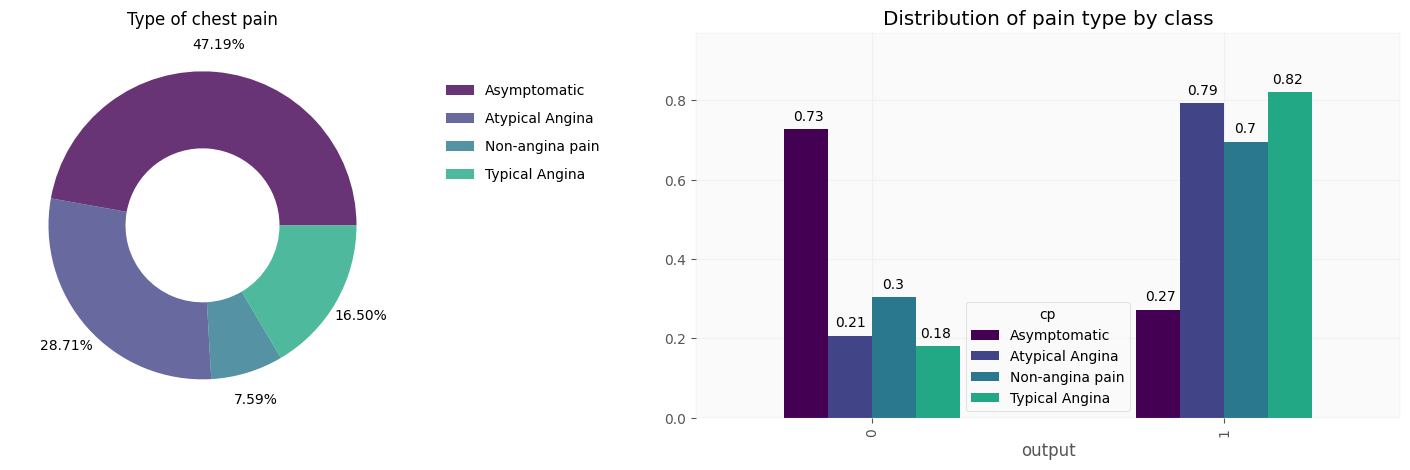

In [ ]:
# Data for the pie chart
attr = 'cp'
pie_title = 'Type of chest pain'
figsize = (20, 5)
bar_title = 'Distribution of pain type by class'
initial = 0.18
step = 0.12

charts = CategoricalDistribuition(attr, pie_title, figsize, bar_title, initial, step)
charts.display_plot(df)

Angina is a medical condition characterized by chest pain or discomfort. The graph shows that 47% of patients are asymptomatic with respect to this pain, and that there is a high probability that asymptomatic individuals have less than 50% narrowing of the coronary arteries, which significantly reduces the likelihood of heart disease in this group. Patients with other types of pain, however, have a high probability of having more than 50% narrowing of the coronary arteries, which increases the chances of heart disease.

/tmp/ipykernel_21512/2020089303.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=self.attr, x="output", data=df, palette=coresViridis, ax=ax2)
/tmp/ipykernel_21512/2020089303.py:26: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(y=self.attr, x="output", data=df, palette=coresViridis, ax=ax2)


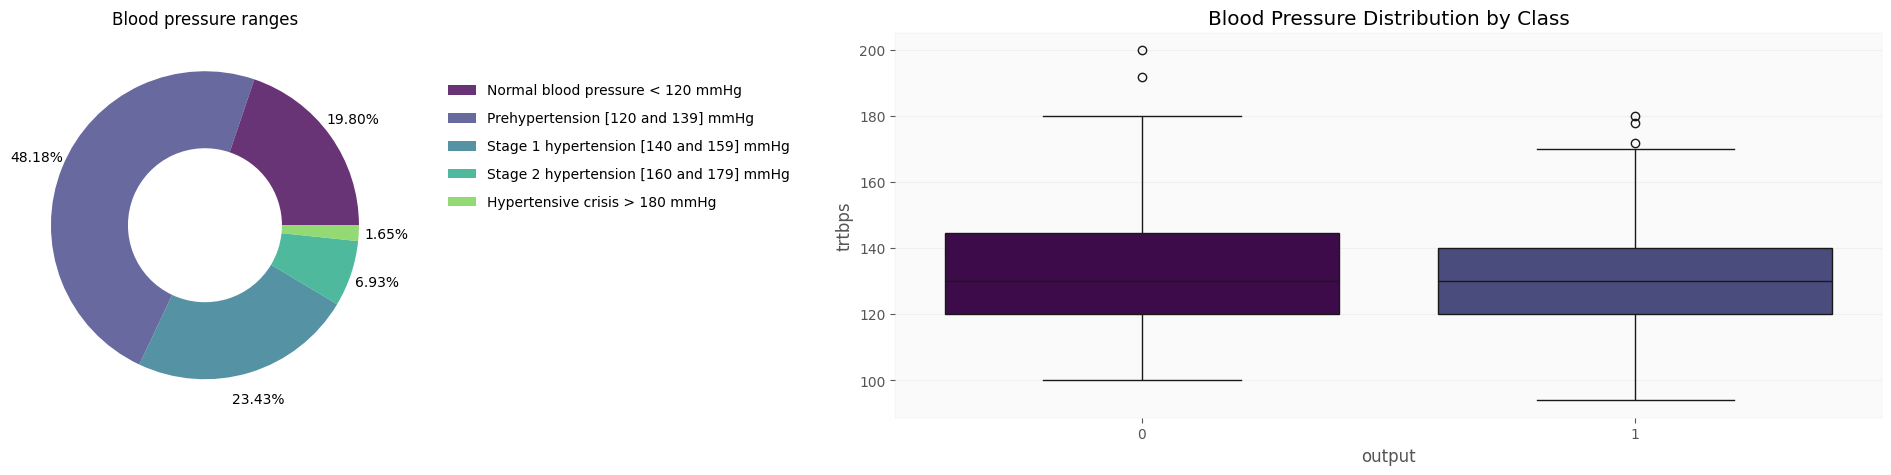

In [ ]:
# Data for the pie chart
attr = 'trtbps'
pie_title = 'Blood pressure ranges'
box_plot_title = 'Blood Pressure Distribution by Class'
figsize = (28, 5)
pie_legends = [
                'Normal blood pressure < 120 mmHg',
                'Prehypertension [120 and 139] mmHg',
                'Stage 1 hypertension [140 and 159] mmHg',
                'Stage 2 hypertension [160 and 179] mmHg',
                'Hypertensive crisis > 180 mmHg'
              ]


class TrtbpsChart(NumericalDistribuition):
    def grouping(value):
        if value < 120:
            return 0
        elif value >= 120 and value <= 139:
            return 1
        elif value >= 140 and value <= 159:
            return 2
        elif value >= 160 and value <= 179:
            return 3
        else:
            return 4

charts = TrtbpsChart(attr, pie_title, pie_legends, figsize, box_plot_title)
charts.display_plot(df, TrtbpsChart)

Considering that blood pressure was measured at rest, more than 80% of the patients in the sample had blood pressure above what is considered normal. The difference between the distributions in the second graph is quite small, since they almost overlap, which probably makes this attribute somewhat less relevant for constructing the classification model. Furthermore, the hypertensive crisis class represents only 1.65% of cases, making this class rare and probably more difficult to classify using the model.

/tmp/ipykernel_21512/2020089303.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=self.attr, x="output", data=df, palette=coresViridis, ax=ax2)
/tmp/ipykernel_21512/2020089303.py:26: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(y=self.attr, x="output", data=df, palette=coresViridis, ax=ax2)


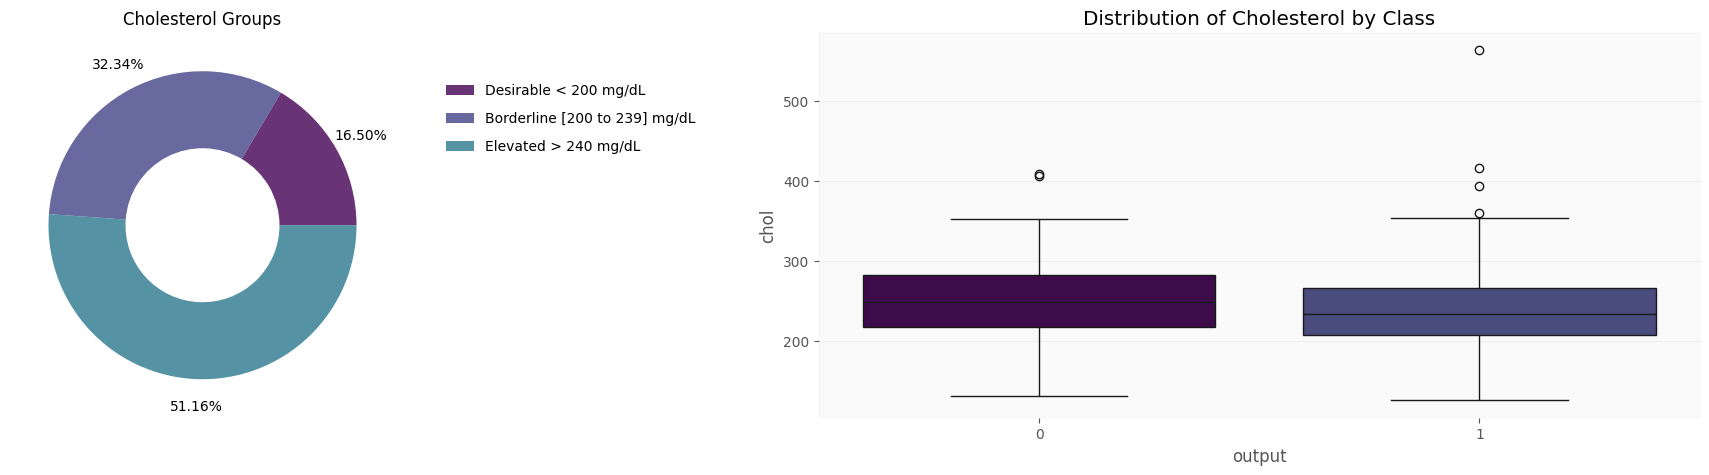

In [ ]:
# Data for the pie chart
attr = 'chol'
pie_title = 'Cholesterol Groups'
box_plot_title = 'Distribution of Cholesterol by Class'
figsize = (25, 5)
pie_legends = [
                'Desirable < 200 mg/dL',
                'Borderline [200 to 239] mg/dL',
                'Elevated > 240 mg/dL'
              ]

class CholesterolChart(NumericalDistribuition):
    def grouping(value):
        if value < 200:
            return 0
        elif value >= 200 and value <= 239:
            return 1
        else:
            return 2


charts = CholesterolChart(attr, pie_title, pie_legends, figsize, box_plot_title)
charts.display_plot(df, CholesterolChart)

Note that although more than 80% of patients have cholesterol levels close to the upper limit (borderline) or elevated, the cholesterol distributions by output class practically overlap, but a difference is noticeable between the interquartile ranges, making this attribute relatively irrelevant for the construction of the classification model.

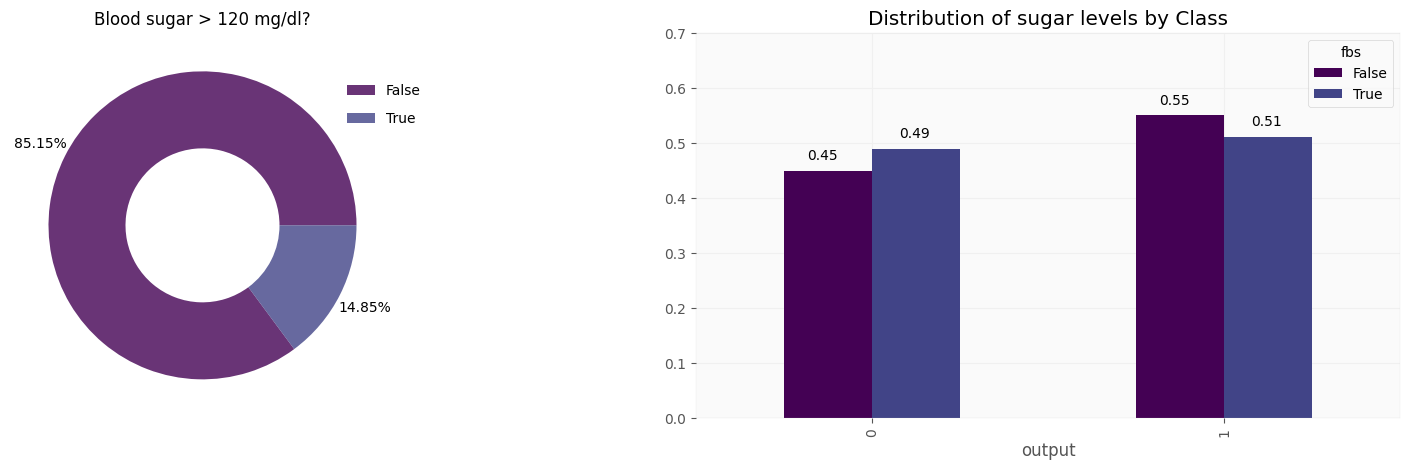

In [ ]:
# Data for the pie chart
attr = 'fbs'
pie_title = 'Blood sugar > 120 mg/dl?'
figsize = (20, 5)
bar_title = 'Distribution of sugar levels by Class'
initial = 0.14
step = 0.26

charts = CategoricalDistribuition(attr, pie_title, figsize, bar_title, initial, step)
charts.display_plot(df)

Over 85% of the sample has sugar levels considered normal, and yet the distributions between the classes almost overlap, which indicates a probably very low relevance of this attribute for the construction of the model.

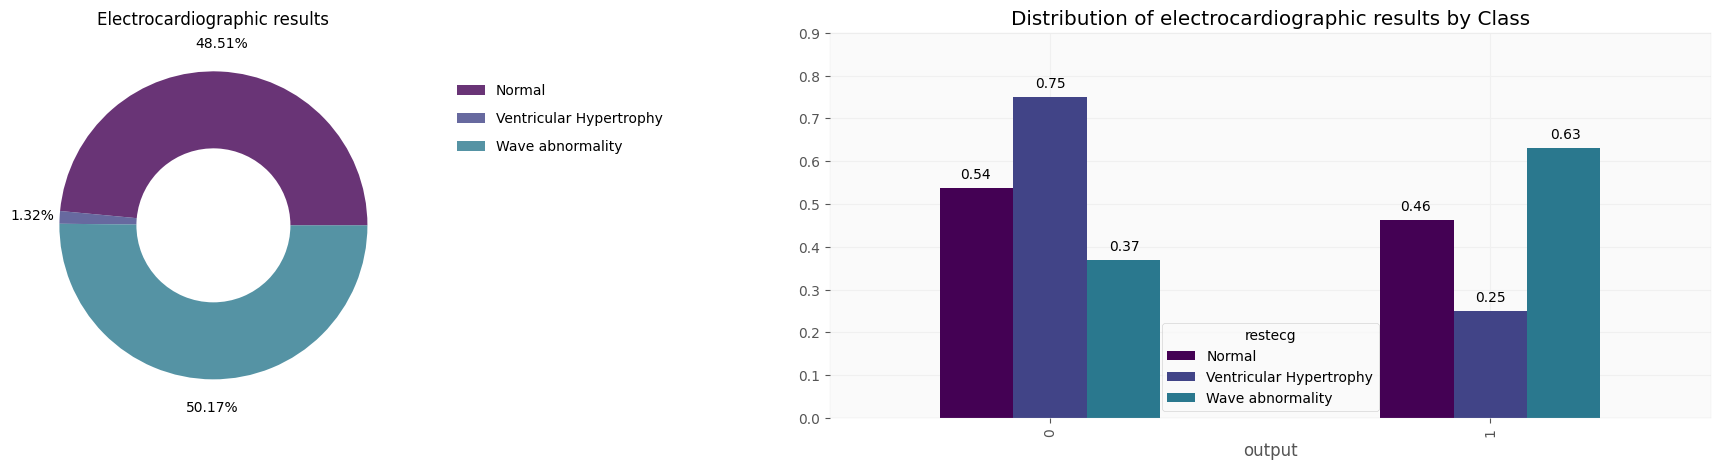

In [ ]:
# Data for the pie chart
attr = 'restecg'
pie_title = 'Electrocardiographic results'
figsize = (25, 5)
bar_title = 'Distribution of electrocardiographic results by Class'
initial = 0.17
step = 0.17

charts = CategoricalDistribuition(attr, pie_title, figsize, bar_title, initial, step)
charts.display_plot(df)

It is noticeable that patients who presented wave abnormalities in electrocardiographic results have a higher chance of having more than 50% narrowing of the coronary artery diameter. The same does not occur with the other results of the electrocardiographic tests. In any case, we see very distinct distributions by output class only with regard to the **wave abnormality** class, which indicates that this attribute may be relevant for the construction of the model with respect to this class. The low representation of patients with ventricular hypertrophy probably makes this attribute class very difficult to classify in relation to the output class.

/tmp/ipykernel_21512/928538720.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(y=attr, x="output", data=df, palette=coresViridis)
/tmp/ipykernel_21512/928538720.py:6: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.boxplot(y=attr, x="output", data=df, palette=coresViridis)


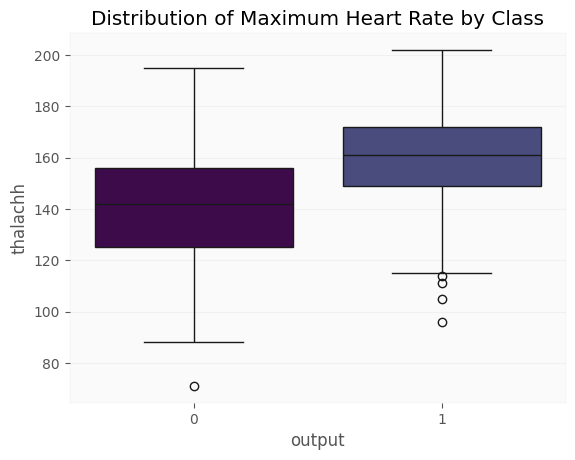

In [ ]:
# Data for the pie chart
attr = 'thalachh'
box_plot_title = 'Distribution of Maximum Heart Rate by Class'

# Plot the boxplot along the second axis.
ax = sns.boxplot(y=attr, x="output", data=df, palette=coresViridis)

# Adjust the titles and captions
ax.set_title(box_plot_title)

plt.show()

It is not possible to group the maximum heart rates achieved into classes, as this will depend on several factors involving age, sex, and level of sedentary behavior. However, it is possible to see how the distributions of this attribute across the output class differ completely, which makes this attribute likely highly relevant to the model.

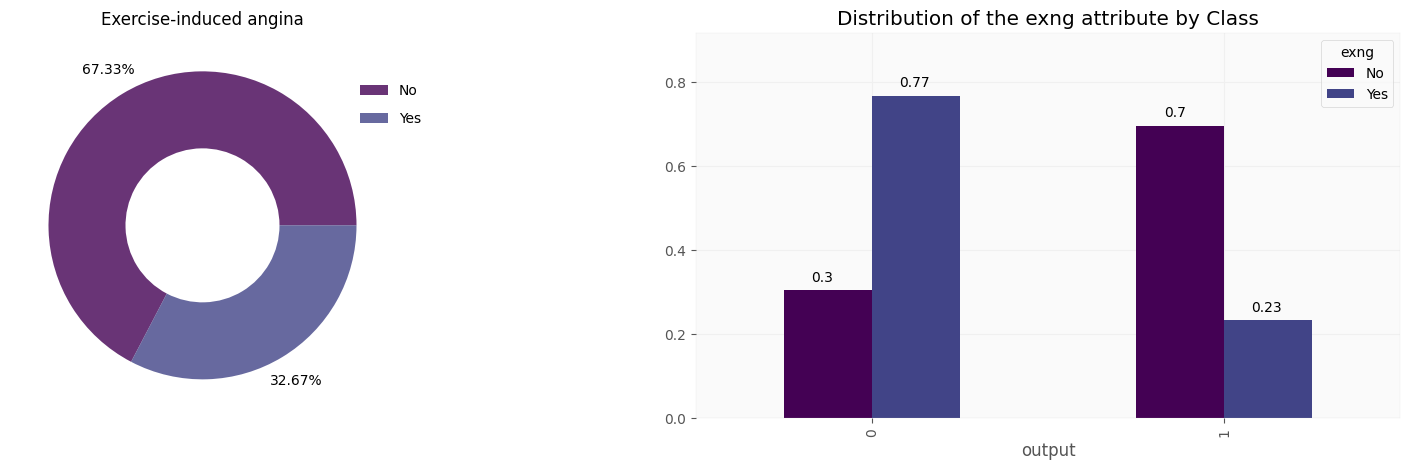

In [ ]:
# Data for the pie chart
attr = 'exng'
pie_title = 'Exercise-induced angina'
figsize = (20, 5)
bar_title = 'Distribution of the exng attribute by Class'
initial = 0.14
step = 0.26

charts = CategoricalDistribuition(attr, pie_title, figsize, bar_title, initial, step)
charts.display_plot(df)

Exercise-induced angina is a condition characterized by chest pain or discomfort that occurs during or after intense physical activity, such as running, cycling, or playing sports. What we see above is that more than 67% did not present with exercise-induced angina, but despite this, people who do not experience this pain have a higher probability of having more than 50% narrowing of the coronary arteries, which could indicate a higher probability of heart disease.

/tmp/ipykernel_21512/2020089303.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=self.attr, x="output", data=df, palette=coresViridis, ax=ax2)
/tmp/ipykernel_21512/2020089303.py:26: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(y=self.attr, x="output", data=df, palette=coresViridis, ax=ax2)


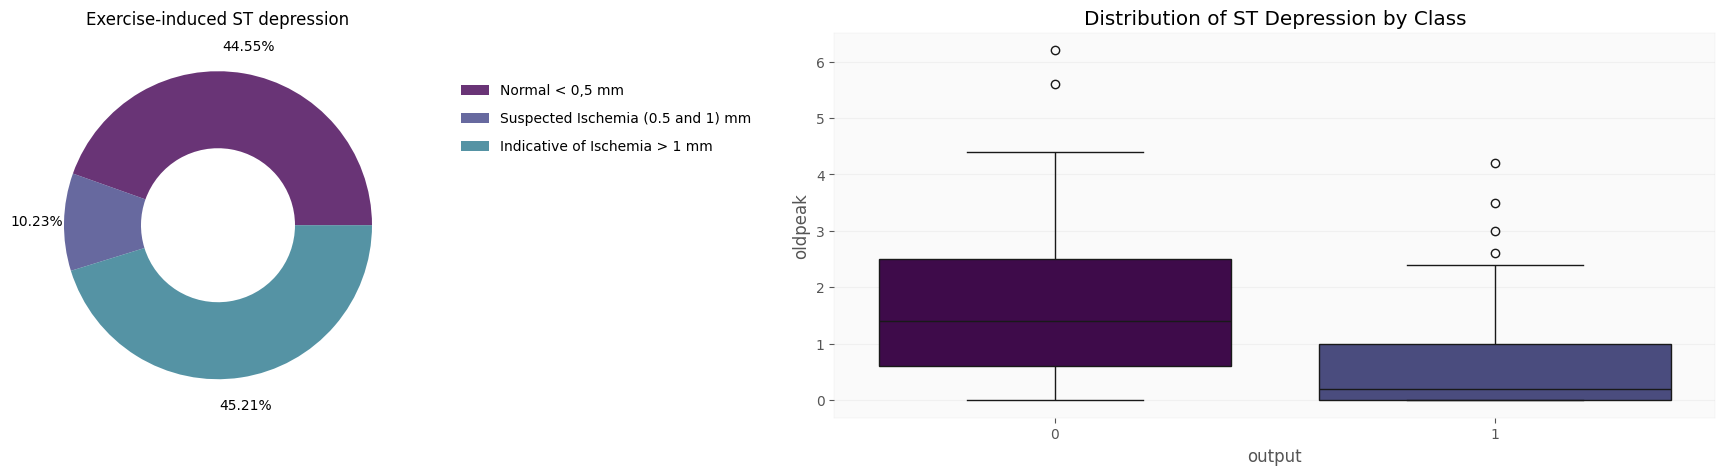

In [ ]:
# Data for the pie chart
attr = 'oldpeak'
pie_title = 'Exercise-induced ST depression'
box_plot_title = 'Distribution of ST Depression by Class'
figsize = (25, 5)
pie_legends = [
                'Normal < 0,5 mm',
                'Suspected Ischemia (0.5 and 1) mm',
                'Indicative of Ischemia > 1 mm'
              ]

class OldpeakChart(NumericalDistribuition):
    def grouping(value):
        if value <= 0.5:
            return 0
        elif value > 0.5 and value < 1:
            return 1
        else:
            return 2


charts = OldpeakChart(attr, pie_title, pie_legends, figsize, box_plot_title)
charts.display_plot(df, OldpeakChart)

The European Society of Cardiology (ESC) defines the following classification for ST segment depression during stress testing:

 - ST segment depression of 0.5 mm or less: considered normal;
 - ST segment depression between 0.5 mm and 1 mm: considered suspicious for ischemia;
 - ST segment depression of 1 mm or more: considered indicative of significant ischemia.

Despite the classification proposed by the ESC, the distribution above shows an interquartile range between 0 and 1 mm of ST depression for people diagnosed with more than 50% narrowing of the coronary artery diameter. The distributions are quite skewed, which makes this attribute likely valuable for model building.

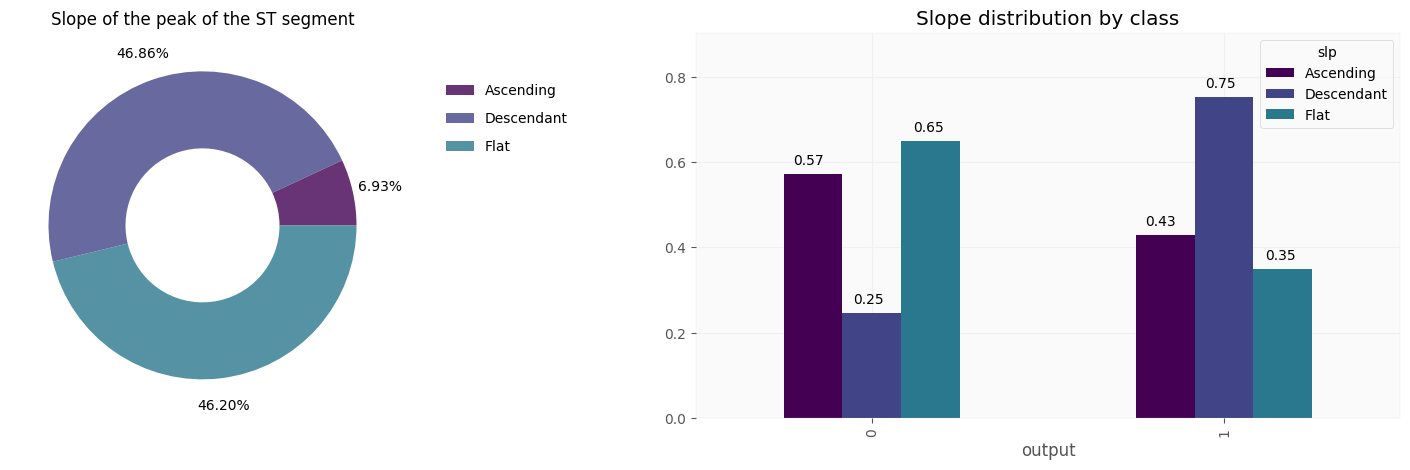

In [ ]:
# Data for the pie chart
attr = 'slp'
pie_title = 'Slope of the peak of the ST segment'
figsize = (20, 5)
bar_title = 'Slope distribution by class'
initial = 0.18
step = 0.17

charts = CategoricalDistribuition(attr, pie_title, figsize, bar_title, initial, step)
charts.display_plot(df)

Above, we see that people with a downward slope of the ST segment peak are more likely to have more than 50% narrowing of the coronary artery diameter. This does not occur in other cases. The distributions of the ST segment peak slope by class show large differences, making this attribute probably very relevant for the construction of the model, except for the ascending class which has low representation.

/tmp/ipykernel_21512/2020089303.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=self.attr, x="output", data=df, palette=coresViridis, ax=ax2)
/tmp/ipykernel_21512/2020089303.py:26: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(y=self.attr, x="output", data=df, palette=coresViridis, ax=ax2)


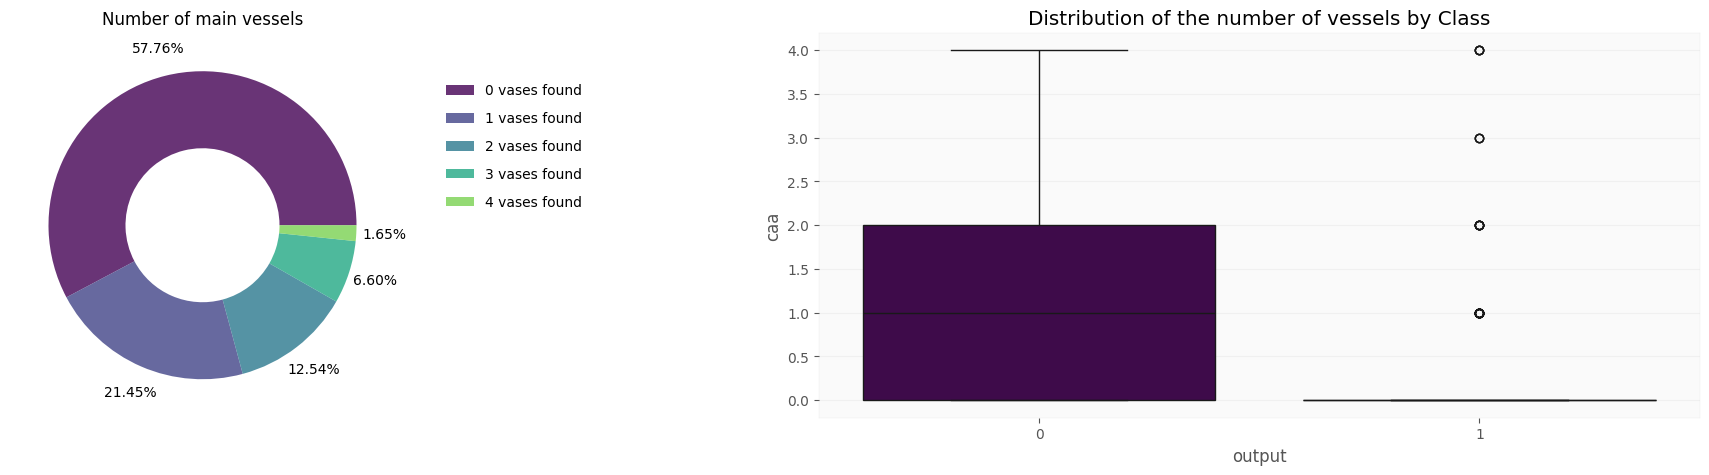

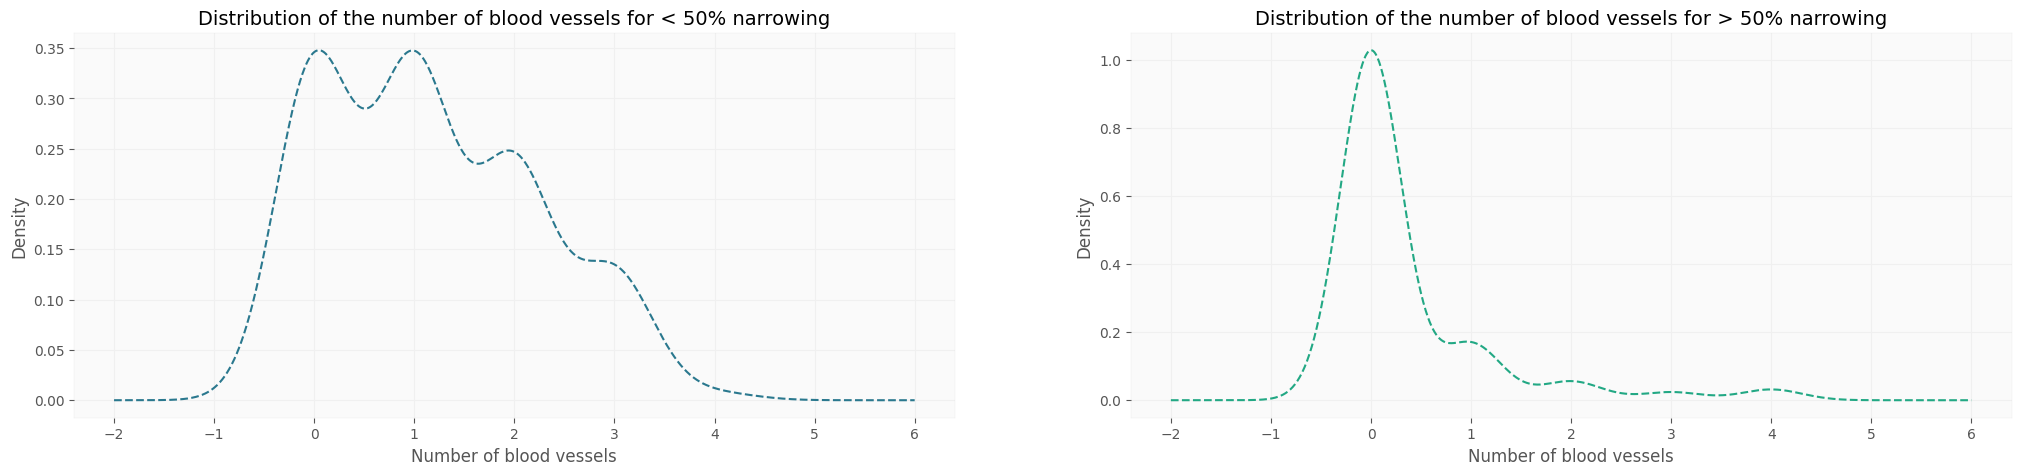

In [ ]:
# Data for the pie chart
attr = 'caa'
pie_title = 'Number of main vessels'
box_plot_title = 'Distribution of the number of vessels by Class'
figsize = (25, 5)
pie_legends = [
                '0 vases found',
                '1 vases found',
                '2 vases found',
                '3 vases found',
                '4 vases found'
              ]


class CAAChart(NumericalDistribuition):
    def grouping(value):
        return value

charts = CAAChart(attr, pie_title, pie_legends, figsize, box_plot_title)
charts.display_plot(df, CAAChart)

fig2, ax = plt.subplots(1, 2, figsize=(25,5), sharey=False)

df[df['output']==0]['caa'].plot.kde(ls='--', color=coresViridis[2], ax=ax[0])
ax[0].set_xlabel('Number of blood vessels', fontsize=12)
ax[0].set_title('Distribution of the number of blood vessels for < 50% narrowing', fontsize=14)

df[df['output']==1]['caa'].plot.kde(ls='--', color=coresViridis[3], ax=ax[1])
ax[1].set_xlabel('Number of blood vessels', fontsize=12)
ax[1].set_title('Distribution of the number of blood vessels for > 50% narrowing', fontsize=14)
plt.show()


Fluoroscopy is a diagnostic imaging procedure that uses X-rays to produce real-time images of the body's internal organs, including major blood vessels. However, there may be situations where major blood vessels are not visible or may appear absent in fluoroscopy. Unlike what was discussed above, the heart has four types of major blood vessels: the right and left coronary arteries and the right and left pulmonary arteries. Therefore, we can say that this attribute has no null values ​​or values ​​outside the acceptable range.

This is perhaps one of the most important attributes for helping to build the classification model, due to the striking difference in the attribute's distribution across the two output classes.

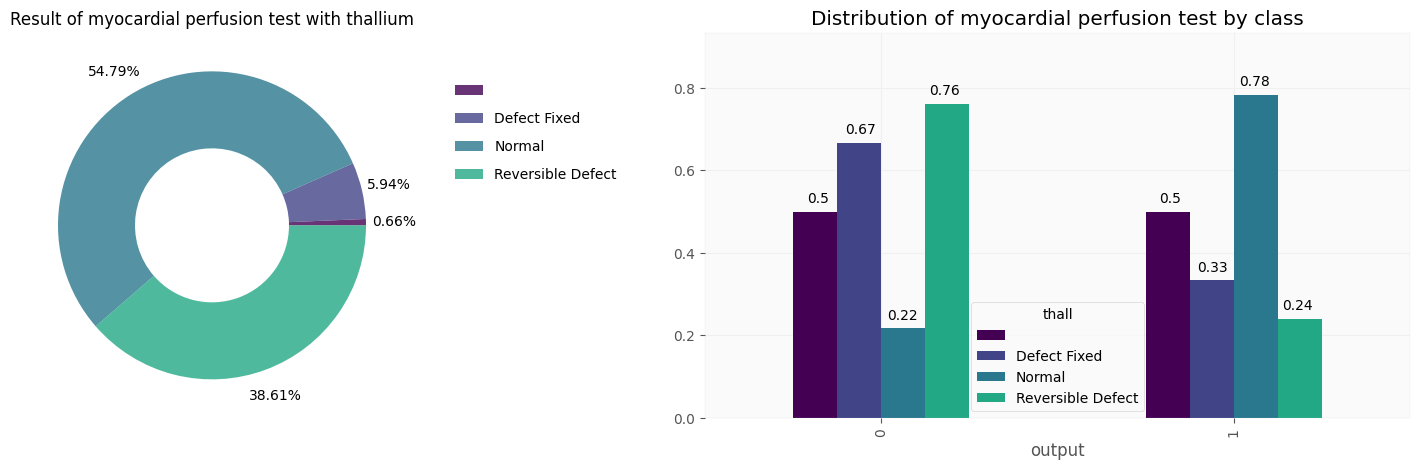

In [ ]:
# Data for the pie chart
attr = 'thall'
pie_title = 'Result of myocardial perfusion test with thallium'
figsize = (20, 5)
bar_title = 'Distribution of myocardial perfusion test by class'
initial = 0.18
step = 0.12

charts = CategoricalDistribuition(attr, pie_title, figsize, bar_title, initial, step)
charts.display_plot(df)

The graphs show that patients with a **normal** result on the thallium myocardial perfusion test are much more likely to have more than 50% narrowing of the coronary artery diameter, which is not the case with other results. It is also noticeable that 0.66% of patients have null values ​​for this attribute; therefore, these values ​​should be addressed in the pre-processing stage. Furthermore, this attribute is likely valuable for constructing the classification model, with very distinct distributions and good representativeness among the classes, except for the **corrected defect** class.

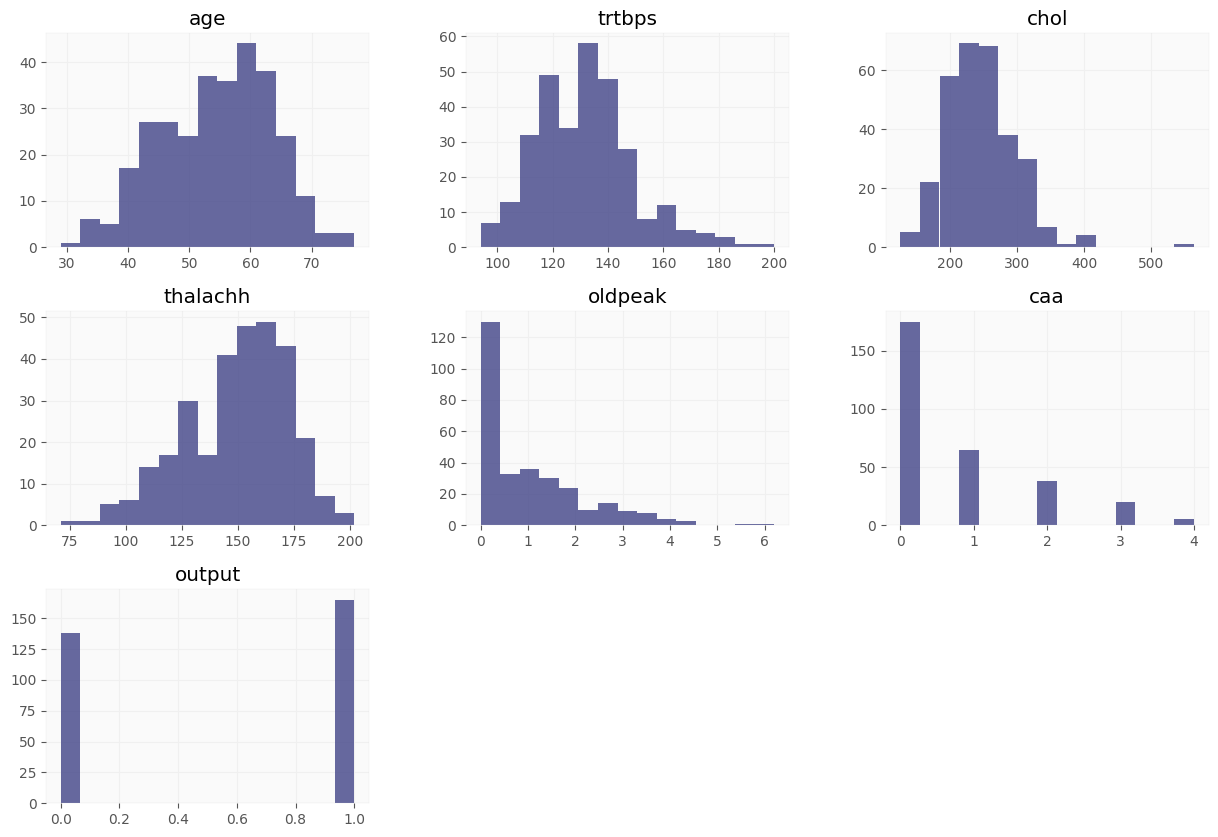

In [ ]:
# Histograms
df.hist(figsize = (15,10), bins=15, alpha=0.8, color=corDefault)
plt.show()

The distribution of the **age** attribute shows the modal class to be slightly different from the mean. The **trtbps** and **chol** attributes, however, show a modal class that is somewhat closer to the mean, which could characterize approximately normal distributions. The remaining attributes show a clearly exponential distribution.



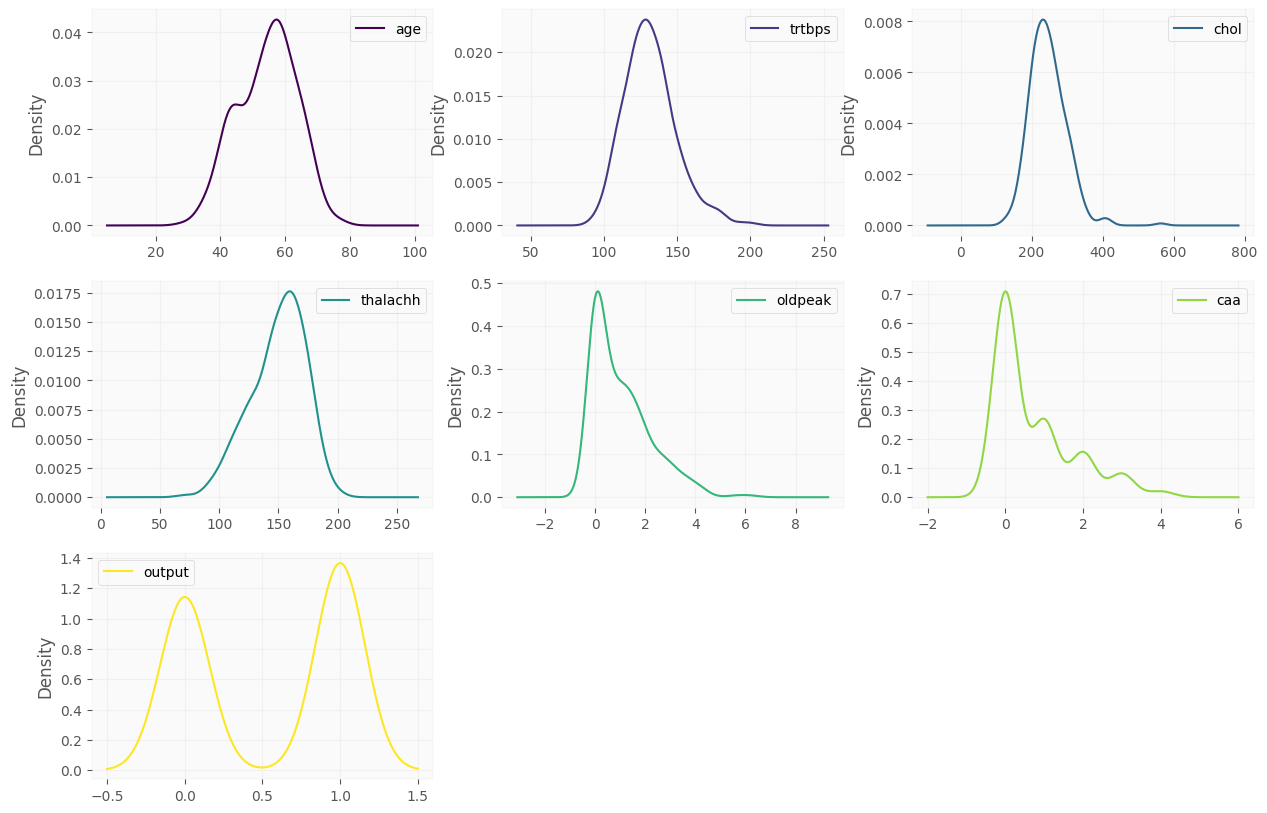

In [ ]:
# Density Plot
df.plot(kind = 'density', subplots = True, layout = (3,3), sharex = False, figsize = (15,10), colormap='viridis')
plt.show()

The density plot for the age attribute shows a curve close to a bell curve, while the trtbps and chol attributes show an almost perfect bell curve. The remaining attributes (except for output) are confirmed as exponential distributions. Therefore, we see that it is necessary to apply both normalization techniques and data standardization.

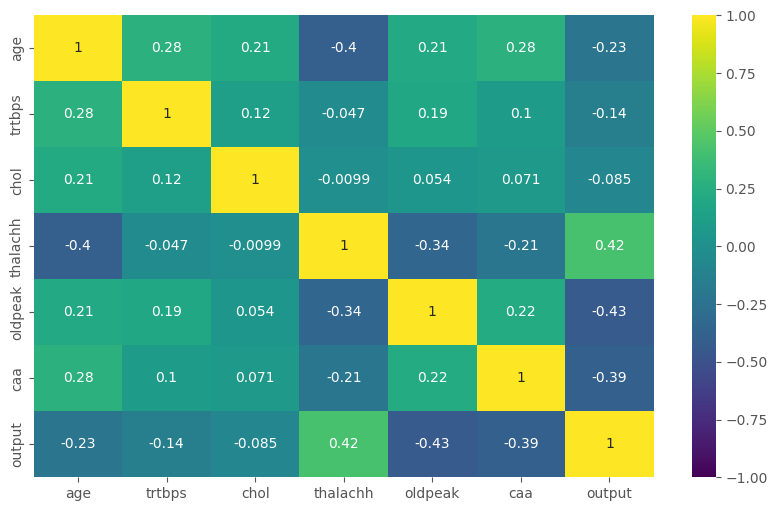

In [ ]:
# Correlation Matrix with Seaborn
plt.figure(figsize = (10, 6))
sns.heatmap(df[['age', 'trtbps', 'chol', 'thalachh', 'oldpeak', 'caa', 'output']].corr(), annot=True, cmap='viridis', vmin=-1, vmax=1);

The correlation matrix shown above does not show any moderate or strong correlations, which is highly beneficial, since highly correlated attributes can affect the model's accuracy.

## 4. Data Preprocessing

In this step, we will perform some data preparation operations for building the model. Initially, we will start by addressing missing values.

### 4.1 Data Cleanup

In [ ]:
# checking for nulls in the dataset
df.isnull().sum()

,0
age,0
sex,0
cp,0
trtbps,0
chol,0
fbs,0
restecg,0
thalachh,0
exng,0
oldpeak,0


Above, we don't see any null values; however, during exploratory analysis, we identified null values ​​for the **thall** attribute. To process this data, we will fill in these values ​​using the mode.

In [ ]:
# Saving a NEW dataset to handle missing data so as not to overwrite the original dataset.

# retrieving column names
col = list(df.columns)

# The new dataset will contain all columns except the last one (class).
new_df = df[col[0:-1]].copy()

# Replacing the zeros with the mode in the new dataframe
new_df['thall'] = df['thall'].apply(lambda x: df['thall'].mode()[0] if (x == '') else x)

# Replacing the zeros with the mode in the original dataframe
df_src['thall'] = df_src['thall'].apply(lambda x: int(df_src['thall'].mode()) if (x == 0) else int(x))

new_df['thall'].value_counts()

/tmp/ipykernel_21512/3766349346.py:13: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  df_src['thall'] = df_src['thall'].apply(lambda x: int(df_src['thall'].mode()) if (x == 0) else int(x))
/tmp/ipykernel_21512/3766349346.py:13: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  df_src['thall'] = df_src['thall'].apply(lambda x: int(df_src['thall'].mode()) if (x == 0) else int(x))


,count
thall,
Normal,168
Reversible Defect,117
Defect Fixed,18


In [ ]:
df_src['thall'].value_counts()

,count
thall,
2,168
3,117
1,18


### 4.2 Encoding Categorical Variables

We will use the One-hot encoding technique to encode categorical variables. This technique is useful for allowing ML algorithms to work with categorical data, which normally cannot be processed directly by these algorithms.

In [ ]:
# Selecting categorical attributes
attrs = ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'thall']

# Applying one-hot encoding to categorical attributes without redundant classes.
selected_features = pd.get_dummies(new_df, prefix=attrs, columns=attrs, drop_first=True)
selected_features

,age,trtbps,chol,thalachh,oldpeak,caa,sex_Male,cp_Atypical Angina,cp_Non-angina pain,cp_Typical Angina,fbs_True,restecg_Ventricular Hypertrophy,restecg_Wave abnormality,exng_Yes,slp_Descendant,slp_Flat,thall_Normal,thall_Reversible Defect
0,63,145,233,150,2.3,0,True,False,True,False,True,False,False,False,False,False,False,False
1,37,130,250,187,3.5,0,True,True,False,False,False,False,True,False,False,False,True,False
2,41,130,204,172,1.4,0,False,False,False,True,False,False,False,False,True,False,True,False
3,56,120,236,178,0.8,0,True,False,False,True,False,False,True,False,True,False,True,False
4,57,120,354,163,0.6,0,False,False,False,False,False,False,True,True,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,140,241,123,0.2,0,False,False,False,False,False,False,True,True,False,True,False,True
299,45,110,264,132,1.2,0,True,False,True,False,False,False,True,False,False,True,False,True
300,68,144,193,141,3.4,2,True,False,False,False,True,False,True,False,False,True,False,True
301,57,130,131,115,1.2,1,True,False,False,False,False,False,True,True,False,True,False,True


Above, it's possible to see that classes with low representation, such as **ventricular hypertrophy** and **non-angina pain**, became attributes, and these classes likely gave way to classes with higher representation, which could affect the final accuracy of the model. Therefore, I think it's interesting to use one-hot encoding without removing redundancies, even to create two types of models for comparison purposes.

In [ ]:
# Applying one-hot encoding to categorical attributes without removing redundant ones
all_features = pd.get_dummies(new_df, prefix=attrs, columns=attrs)
all_features

,age,trtbps,chol,thalachh,oldpeak,caa,sex_Female,sex_Male,cp_Asymptomatic,cp_Atypical Angina,...,restecg_Ventricular Hypertrophy,restecg_Wave abnormality,exng_No,exng_Yes,slp_Ascending,slp_Descendant,slp_Flat,thall_Defect Fixed,thall_Normal,thall_Reversible Defect
0,63,145,233,150,2.3,0,False,True,False,False,...,False,False,True,False,True,False,False,True,False,False
1,37,130,250,187,3.5,0,False,True,False,True,...,False,True,True,False,True,False,False,False,True,False
2,41,130,204,172,1.4,0,True,False,False,False,...,False,False,True,False,False,True,False,False,True,False
3,56,120,236,178,0.8,0,False,True,False,False,...,False,True,True,False,False,True,False,False,True,False
4,57,120,354,163,0.6,0,True,False,True,False,...,False,True,False,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,140,241,123,0.2,0,True,False,True,False,...,False,True,False,True,False,False,True,False,False,True
299,45,110,264,132,1.2,0,False,True,False,False,...,False,True,True,False,False,False,True,False,False,True
300,68,144,193,141,3.4,2,False,True,True,False,...,False,True,True,False,False,False,True,False,False,True
301,57,130,131,115,1.2,1,False,True,True,False,...,False,True,False,True,False,False,True,False,False,True


### 4.3 Feature Selection

We will use the dataframe with all the features generated by one-hot encoding to perform feature selection.

In [ ]:
# Dividing the dataset into inputs and outputs.
X = all_features
y = df['output']

# Selecting the best attributes using the chi2 function
selector = SelectKBest(chi2, k = 18)
X_new = selector.fit(X, y)

# Creating a comparison table
df_scores = pd.DataFrame(X_new.scores_)
df_columns = pd.DataFrame(X.columns)
feature_scores = pd.concat([df_columns, df_scores], axis = 1)
feature_scores.columns = ['Specs','Score']
feature_scores.sort_values('Score', ascending=False)

,Specs,Score
3,thalachh,188.320472
4,oldpeak,72.644253
5,caa,66.440765
24,thall_Reversible Defect,43.952735
8,cp_Asymptomatic,42.603378
18,exng_Yes,38.914377
23,thall_Normal,37.474311
20,slp_Descendant,25.001417
2,chol,23.936394
0,age,23.286624


From the exploratory analysis, it was possible to identify categorical attributes that had classes with low representativeness and/or that did not have a significant difference in the distributions of the input categorical classes by the output classes, which in most cases resulted in low relevance attributes for the model through one-hot encoding. These attributes are: **sex_Male**, **cp_Non-angina pain**, **restecg_Ventricular Hypertrophy**, **exng_No**, **slp_Ascending**, **thall_Defect Fixed**. Furthermore, the fsb attribute produced very low relevance for both classes: **fbs_True** and **fbs_False**.


In [ ]:
cols = ['sex_Male', 'cp_Non-angina pain', 'restecg_Ventricular Hypertrophy',
        'exng_No', 'slp_Ascending', 'thall_Defect Fixed',
        'fbs_True', 'fbs_False']

final_features = all_features.drop(cols, axis=1)
final_features

,age,trtbps,chol,thalachh,oldpeak,caa,sex_Female,cp_Asymptomatic,cp_Atypical Angina,cp_Typical Angina,restecg_Normal,restecg_Wave abnormality,exng_Yes,slp_Descendant,slp_Flat,thall_Normal,thall_Reversible Defect
0,63,145,233,150,2.3,0,False,False,False,False,True,False,False,False,False,False,False
1,37,130,250,187,3.5,0,False,False,True,False,False,True,False,False,False,True,False
2,41,130,204,172,1.4,0,True,False,False,True,True,False,False,True,False,True,False
3,56,120,236,178,0.8,0,False,False,False,True,False,True,False,True,False,True,False
4,57,120,354,163,0.6,0,True,True,False,False,False,True,True,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,140,241,123,0.2,0,True,True,False,False,False,True,True,False,True,False,True
299,45,110,264,132,1.2,0,False,False,False,False,False,True,False,False,True,False,True
300,68,144,193,141,3.4,2,False,True,False,False,False,True,False,False,True,False,True
301,57,130,131,115,1.2,1,False,True,False,False,False,True,True,False,True,False,True


### 4.4 Separation into training and test sets

Now we have two dataframes to train the model and perform a comparison: the dataframe with the selected features and the dataframe generated by one-hot encoding with the random removal of redundant attributes.

In [ ]:
test_size = 0.20
seed = 7

# Separation into training and test sets (dataset generated by one-hot encoding)
X = selected_features.values
y = df['output'].values

X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=test_size, shuffle=True, random_state=seed, stratify=y)

In [ ]:
# Separation into training and test sets (dataset with selected features)
X_fs = final_features.values
y_fs = df['output'].values

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(X_fs, y_fs,
    test_size=test_size, shuffle=True, random_state=seed, stratify=y_fs)

In [ ]:
# Getting the name of all the columns
col = list(df_src.columns)

# Separation into training and test sets (original dataset)
X_src = df_src[col[0:-1]].values

X_train_src, X_test_src, y_train_src, y_test_src = train_test_split(X, y,
    test_size=test_size, shuffle=True, random_state=seed, stratify=y)

### 4.5 Standardization and Normalization

Now we perform data normalization with a non-Gaussian distribution, and data standardization with a Gaussian distribution. The attributes that have a normal distribution or are closest to normal are the first three: **age**, **trtbps**, **chol**. The remaining attributes do not follow a normal distribution.

In [ ]:
# Normalizing the data
normalized_X = MinMaxScaler().fit_transform(X_train[:,3:6])

# Standardizing the data
standardized_X = StandardScaler().fit_transform(X_train[:,0:3])

# Reconcatenate the normalized and standardized attributes.
X_train_reshaped = np.hstack((standardized_X, normalized_X, X_train[:,6:]))

In [ ]:
# Normalizing the data
normalized_X = MinMaxScaler().fit_transform(X_train_fs[:,3:6])

# Standardizing the data
standardized_X = StandardScaler().fit_transform(X_train_fs[:,0:3])

# Reconcatenate the normalized and standardized attributes.
X_train_fs_reshaped = np.hstack((standardized_X, normalized_X, X_train_fs[:,6:]))

In [ ]:
# Normalizing all data except categorical data.
normalized_all_X = MinMaxScaler().fit_transform(X_train[:,0:6])

# Standardizing all data except categorical data.
standardized_all_X = StandardScaler().fit_transform(X_train[:,0:6])

# Re-concatenate the normalized attributes to the categorical attributes (dataset generated by one-hot encoding).
X_train_all_norm_ohe = np.hstack((normalized_all_X, X_train[:,6:]))

# Re-concatenate the normalized attributes to the categorical attributes (dataset generated by one-hot encoding).
X_train_all_stand_ohe = np.hstack((standardized_all_X, X_train[:,6:]))

# Re-concatenate the normalized attributes to the categorical attributes (dataset with selected features)
X_train_all_norm_selected = np.hstack((normalized_all_X, X_train_fs[:,6:]))

# Re-concatenate the normalized attributes to the categorical attributes (dataset with selected features)
X_train_all_stand_selected = np.hstack((standardized_all_X, X_train_fs[:,6:]))

The models should be trained using the following datasets:

1. **X_train_src, y_train_src**: For testing with the original dataset;

2. **X_train_all_norm_ohe, y_train**: For testing with the normalized dataset generated by one-hot encoding, excluding redundant classes;

3. **X_train_all_stand_ohe, y_train**: For testing with the standardized dataset generated by one-hot encoding, excluding redundant classes;

4. **X_train_all_norm_selected, y_train_fs**: For testing with the normalized dataset generated by one-hot encoding with subsequent feature selection;

5. **X_train_all_stand_selected, y_train_fs**: For testing with the standardized dataset generated by one-hot encoding with subsequent feature selection;

6. **X_train_reshaped, y_train**: For tests generated by one-hot encoding excluding redundant classes, with standard normal distributions and normalized exponential distributions;

7. **X_train_fs_reshaped, y_train_fs**: For tests generated by one-hot encoding with subsequent feature selection, with standard normal distributions and normalized exponential distributions;
